<a href="https://colab.research.google.com/github/rohitacharya27-rgb/Melbourne-house-price-prediction/blob/main/TITANIC_SURVIVORS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files
uploaded=files.upload()

df=pd.read_csv("titanic.csv")

df.head()

Saving titanic.csv to titanic.csv


,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [2]:
df.tail()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
886,887,"Montvila, Rev. Juozas",2,male,27.0,0,0,211536,13.00,NaN,S,0
887,888,"Graham, Miss. Margaret Edith",1,female,19.0,0,0,112053,30.00,B42,S,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,NaN,1,2,W./C. 6607,23.45,NaN,S,0
889,890,"Behr, Mr. Karl Howell",1,male,26.0,0,0,111369,30.00,C148,C,1
890,891,"Dooley, Mr. Patrick",3,male,32.0,0,0,370376,7.75,NaN,Q,0


In [3]:
df = df.drop(columns=["PassengerId","Name","Ticket","Cabin"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [5]:
df.duplicated().sum()

np.int64(111)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
Pclass,0
Sex,0
Age,104
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0


In [9]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [10]:
df.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0


In [11]:
df['Survived'].value_counts()

,count
Survived,
0,458
1,322


In [12]:
df['Embarked']=df['Embarked'].fillna(df["Embarked"].mode()[0])

<Axes: title={'center': 'Target Class Distribution'}, xlabel='Survived'>

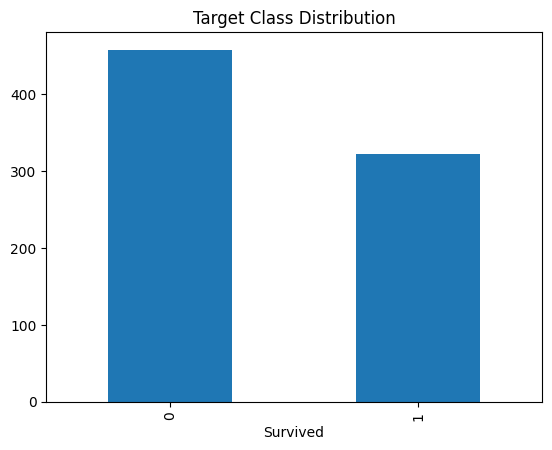

In [13]:
df["Survived"].value_counts().plot(kind="bar", title="Target Class Distribution")

<Axes: title={'center': 'Sex Distribution'}, xlabel='Sex'>

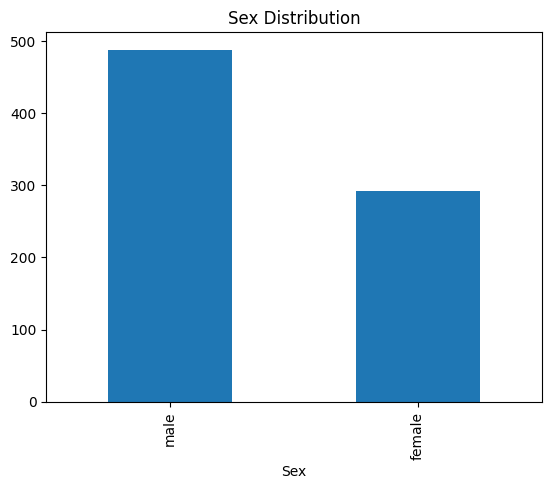

In [14]:
df["Sex"].value_counts().plot(kind="bar", title="Sex Distribution")

<Axes: title={'center': 'Survival by Sex'}, xlabel='Sex'>

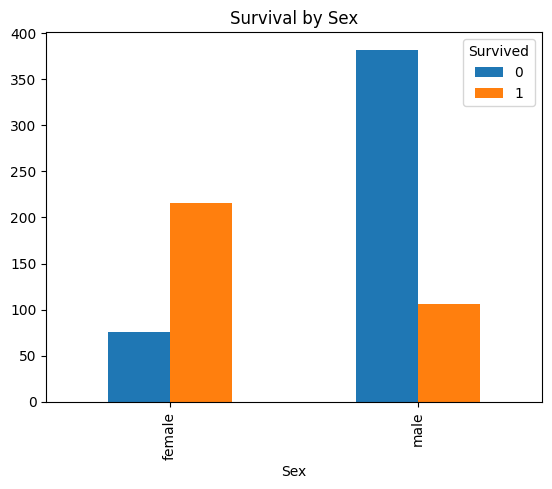

In [15]:
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar", title="Survival by Sex")

<Axes: title={'center': 'Survival by Passenger Class'}, xlabel='Pclass'>

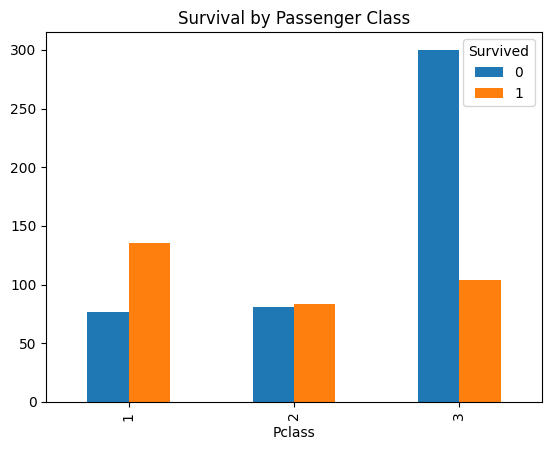

In [16]:
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar", title="Survival by Passenger Class")

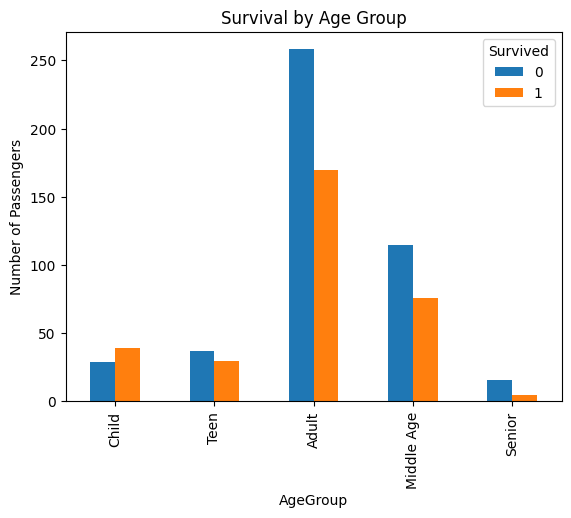

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle Age", "Senior"]
)
pd.crosstab(df["AgeGroup"], df["Survived"]).plot(kind="bar")
plt.title("Survival by Age Group")
plt.ylabel("Number of Passengers")
plt.show()

In [22]:
df.dtypes

,0
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object
Survived,int64
AgeGroup,category


In [23]:
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [24]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [25]:
df["Sex"]=df["Sex"].map({'male':1, 'female':2})

In [26]:
df["Embarked"]=df["Embarked"].map({'S':1, 'C':2, 'Q':3})

In [27]:
df.dtypes

,0
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,int64
Survived,int64
AgeGroup,category


In [28]:
df.duplicated().sum()

np.int64(5)

In [29]:
df[df.duplicated()]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,AgeGroup
55,1,1,28.0,0,0,35.5000,1,1,Adult
105,3,1,28.0,0,0,7.8958,1,0,Adult
507,1,1,28.0,0,0,26.5500,1,1,Adult
826,3,1,28.0,0,0,56.4958,1,0,Adult
868,3,1,28.0,0,0,9.5000,1,0,Adult


In [30]:
df[df.duplicated(keep=False)]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,AgeGroup
23,1,1,28.0,0,0,35.5000,1,1,Adult
29,3,1,28.0,0,0,7.8958,1,0,Adult
55,1,1,28.0,0,0,35.5000,1,1,Adult
105,3,1,28.0,0,0,7.8958,1,0,Adult
169,3,1,28.0,0,0,56.4958,1,0,Adult
200,3,1,28.0,0,0,9.5000,1,0,Adult
430,1,1,28.0,0,0,26.5500,1,1,Adult
507,1,1,28.0,0,0,26.5500,1,1,Adult
826,3,1,28.0,0,0,56.4958,1,0,Adult
868,3,1,28.0,0,0,9.5000,1,0,Adult


In [31]:
df.duplicated().sum()

np.int64(5)

In [32]:
df = df.drop_duplicates()

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0
AgeGroup,0


<Axes: >

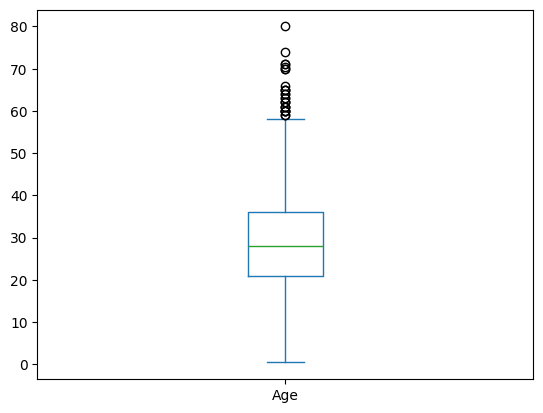

In [35]:
df["Age"].plot(kind="box")

<Axes: >

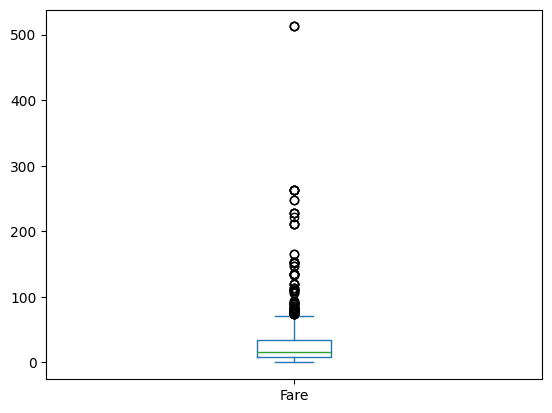

In [ ]:
df["Fare"].plot(kind="box")

<Axes: >

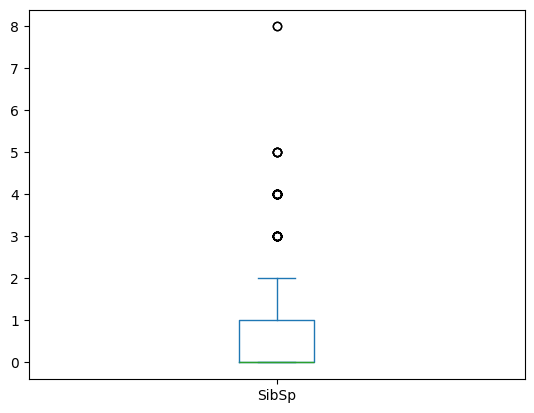

In [ ]:
df["SibSp"].plot(kind="box")

<Axes: >

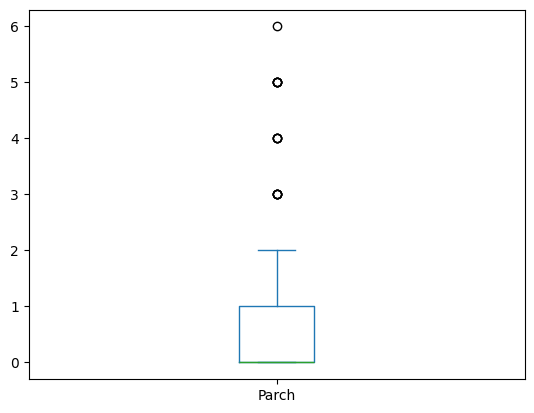

In [ ]:
df["Parch"].plot(kind="box")

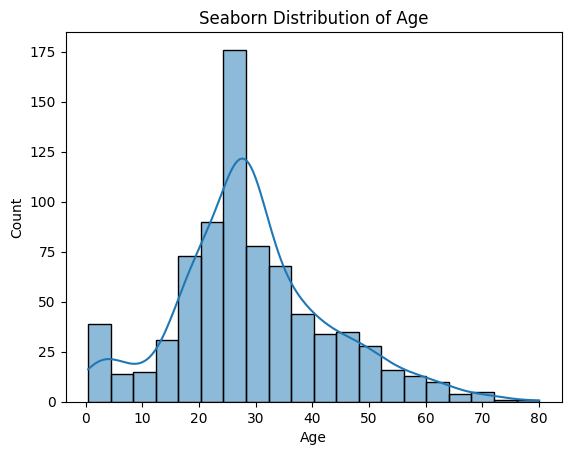

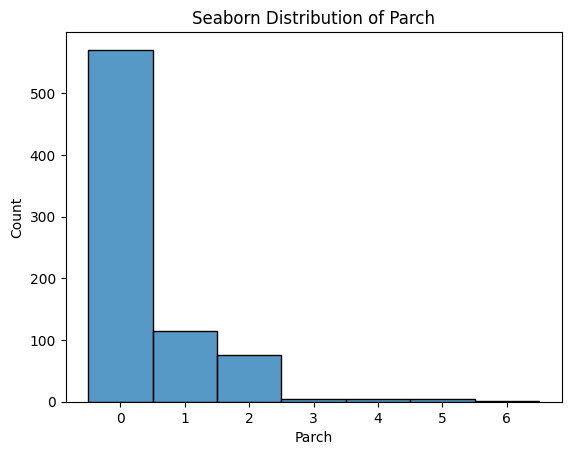

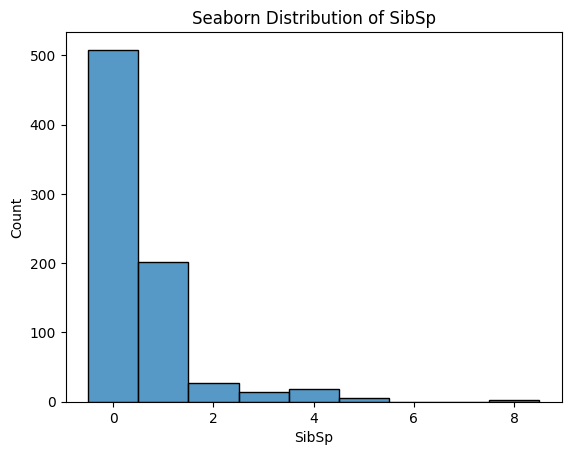

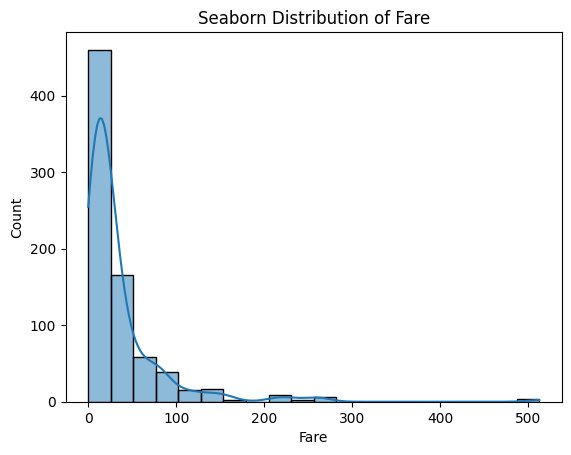

In [38]:
cols_Hist = ['Age', 'Parch', 'SibSp', 'Fare']

for col in cols_Hist:
    plt.figure()

    if col in ['Parch', 'SibSp']:
        sns.histplot(data=df, x=col, discrete=True)
    else:
        sns.histplot(data=df, x=col, bins=20, kde=True)

    plt.title(f'Seaborn Distribution of {col}')
    plt.show()

In [40]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,AgeGroup
0,3,1,22.0,1,0,7.2500,1,0,Adult
1,1,2,38.0,1,0,71.2833,2,1,Middle Age
2,3,2,26.0,0,0,7.9250,1,1,Adult
3,1,2,35.0,1,0,53.1000,1,1,Adult
4,3,1,35.0,0,0,8.0500,1,0,Adult
...,...,...,...,...,...,...,...,...,...
885,3,2,39.0,0,5,29.1250,3,0,Middle Age
887,1,2,19.0,0,0,30.0000,1,1,Adult
888,3,2,28.0,1,2,23.4500,1,0,Adult
889,1,1,26.0,0,0,30.0000,2,1,Adult


In [50]:
df=df.drop(columns=['AgeGroup'])

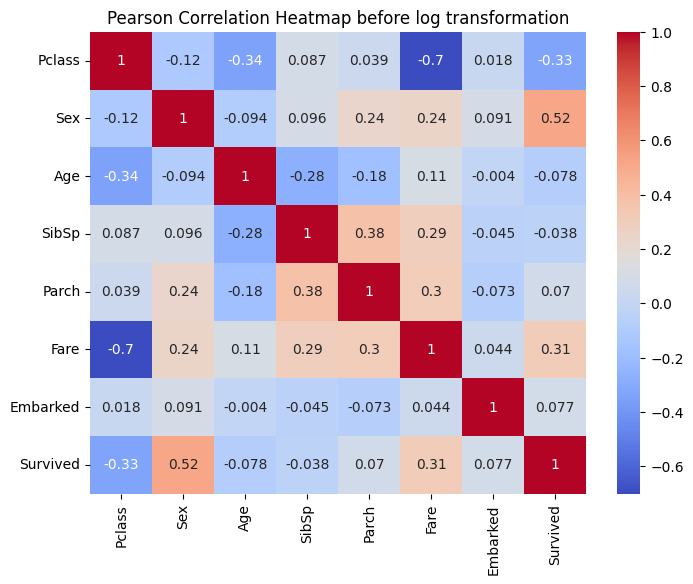

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('Pearson Correlation Heatmap before log transformation')
plt.show()

In [52]:
import numpy as np
df['Fare'] = np.log1p(df['Fare'])

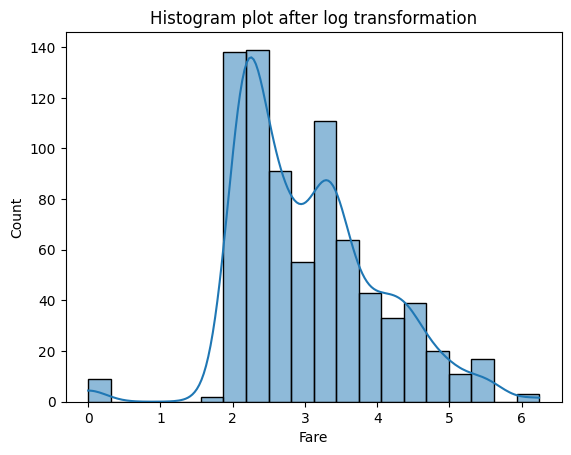

In [62]:
sns.histplot(data=df['Fare'], bins=20, kde=True)
plt.title('Histogram plot after log transformation')
plt.show()

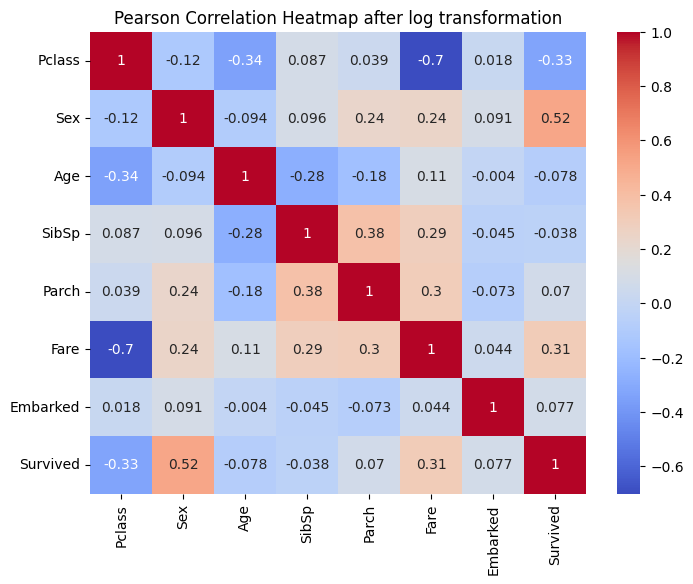

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('Pearson Correlation Heatmap after log transformation')
plt.show()

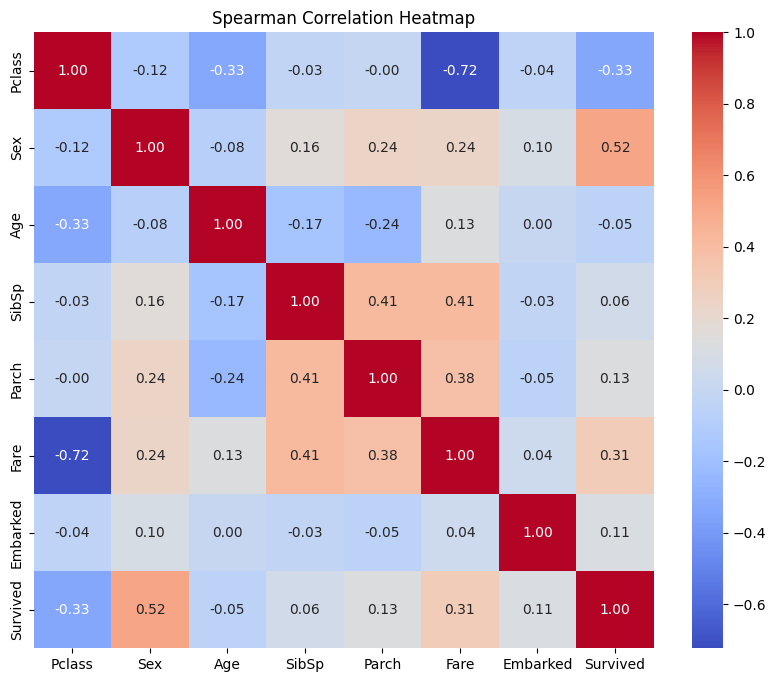

In [67]:
spearman_corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap')
plt.show()

In [68]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,2.110213,1,0
1,1,2,38.0,1,0,4.280593,2,1
2,3,2,26.0,0,0,2.188856,1,1
3,1,2,35.0,1,0,3.990834,1,1
4,3,1,35.0,0,0,2.202765,1,0
...,...,...,...,...,...,...,...,...
885,3,2,39.0,0,5,3.405355,3,0
887,1,2,19.0,0,0,3.433987,1,1
888,3,2,28.0,1,2,3.196630,1,0
889,1,1,26.0,0,0,3.433987,2,1


In [69]:
y = df["Survived"]

In [70]:
X = df.drop("Survived", axis=1)

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [73]:
model=LogisticRegression()

In [74]:
model.fit(X_train, y_train)

LogisticRegression()

In [75]:
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [78]:
accuracy=accuracy_score(y_train,y_train_pred)
print(f"Train Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 76.94%


In [80]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 76.77%


In [81]:
conf_matrix=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[74 17]
 [19 45]]


In [82]:
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        91
           1       0.73      0.70      0.71        64

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



In [83]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

In [84]:
model = RandomForestClassifier(random_state=42)

In [85]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [87]:
rf_Train_pred = model.predict(X_train)
rf_predictions = model.predict(X_test)

In [88]:
print(f'Train Model Accuracy: {accuracy_score(y_train, rf_Train_pred):.2%}')

Train Model Accuracy: 98.06%


In [89]:
print(f'Test Model Accuracy: {accuracy_score(y_test, rf_predictions):.2%}')

Test Model Accuracy: 81.29%


In [90]:
class_report = classification_report(y_test, rf_predictions)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        91
           1       0.79      0.75      0.77        64

    accuracy                           0.81       155
   macro avg       0.81      0.80      0.81       155
weighted avg       0.81      0.81      0.81       155



In [91]:
print(f"Original Tree Depth: {model.estimators_[0].get_depth()}")  #n_estismator default would be 100 trees

Original Tree Depth: 17


In [92]:
tuned_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
tuned_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [93]:
print(f"New Train Accuracy: {tuned_model.score(X_train, y_train):.2%}")
print(f"New Test Accuracy: {tuned_model.score(X_test, y_test):.2%}\n")

New Train Accuracy: 84.52%
New Test Accuracy: 81.94%



In [94]:
importances = pd.Series(tuned_model.feature_importances_, index=X.columns)
print("--- True Feature Importances ---")
print(importances.sort_values(ascending=False))

--- True Feature Importances ---
Sex         0.440377
Fare        0.169728
Pclass      0.167294
Age         0.121472
SibSp       0.047628
Parch       0.031457
Embarked    0.022044
dtype: float64


In [95]:
tuned_preds = tuned_model.predict(X_test)
cm = confusion_matrix(y_test, tuned_preds)

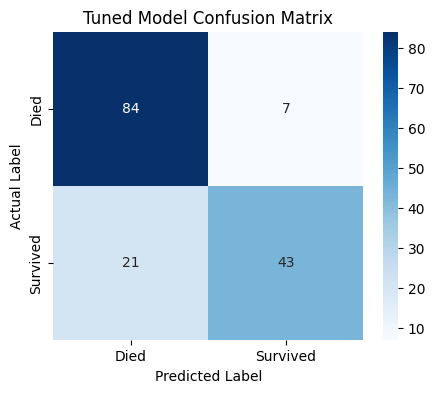

In [97]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Tuned Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()